In [18]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
plt.style.use('default')

In [19]:
### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [21]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
recDir = 'Recordings'

rois = ['S1']
monkey = ['Malfoy', 'Pert']
recordings = {
            'Malfoy': {
                # 'PMd': [19, 20, 21, 22, 23, 24],
                'M1': [12, 13, 25, 27, 28],
                'S1': [5, 9 ,11, 15, 16 ,26, 27, 28]
            },
            'Pert': {
                # 'PMd': [4, 6, 7, 10, 20],
                'M1': [2, 3, 14, 20],
                'S1': []
            }
        }

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre) + 5
t = np.concatenate((t_cue, t_pert))

pcs_plan, pcs_exec = [], []
for roi in rois:
    for mon in monkey:
        for rec in recordings[mon][roi]:
            pcs_ = np.load(os.path.join(baseDir, spkDir, mon, f'pcs.{roi}-{rec}.npy'))
            tinfo = pd.read_csv(os.path.join(baseDir, recDir, mon, f'trial_info-{rec}.tsv'), sep='\t')
            tinfo = tinfo[(tinfo['isCatch'] == 0) & (tinfo['AdaptationBlock']==0)]
            mapping = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
            tinfo.cond = tinfo.cond.map(mapping)
            pcse, _, _ = pcm.group_by_condition(pcs_, tinfo.cond, np.ones(pcs_.shape[1]), axis=1)
            pcs_exec.append(pcse)
            pcsp, _, _ = pcm.group_by_condition(pcs_, tinfo.prob, np.ones(pcs_.shape[1]), axis=1)
            pcs_plan.append(pcsp)
pcs_plan = np.array(pcs_plan).mean(axis=0)
pcs_exec = np.array(pcs_exec).mean(axis=0)

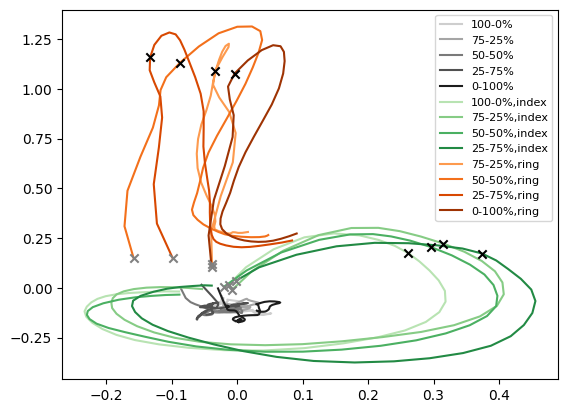

In [22]:
fig, ax = plt.subplots()
pcx, pcy = 2, 0
for c in range(pcs_plan.shape[0]):
    # ax = axs[0]
    ax.plot(pcs_plan[c, cueIdx:cuePost, pcx].T, pcs_plan[c, cueIdx:cuePost, pcy].T, color=list(gl.colour_mapping.values())[c], label=list(gl.colour_mapping.keys())[c])
    ax.plot(pcs_plan[c, pertPre:pertIdx, pcx].T, pcs_plan[c, pertPre:pertIdx, pcy].T, color=list(gl.colour_mapping.values())[c],)
for c in range(pcs_exec.shape[0]):
    ax.plot(pcs_exec[c, pertIdx:, pcx].T, pcs_exec[c, pertIdx:, pcy].T, color=list(gl.colour_mapping.values())[5 + c], label=list(gl.colour_mapping.keys())[c+5])
    ax.scatter(pcs_exec[c, pertIdx+8, pcx].T, pcs_exec[c, pertIdx+8, pcy].T, color='k', marker='x', zorder=1e6)
    ax.scatter(pcs_exec[c, pertIdx, pcx].T, pcs_exec[c, pertIdx, pcy].T, color='grey', marker='x', zorder=1e6)

ax.legend(fontsize=8)
plt.show()

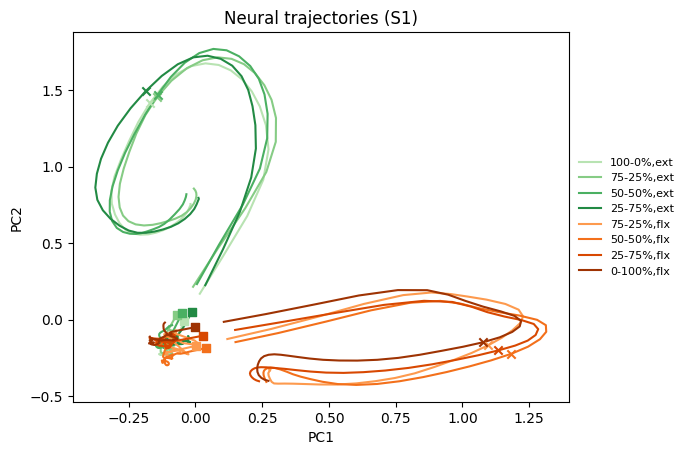

In [30]:
fig, ax = plt.subplots()
pcx, pcy = 0, 1
for c in range(pcs_exec.shape[0]):
    # ax = axs[0]
    ax.plot(pcs_exec[c, cueIdx:cuePost, pcx].T, pcs_exec[c, cueIdx:cuePost, pcy].T, color=list(colour_mapping.values())[5 + c], label=list(colour_mapping.keys())[5 + c])
    ax.plot(pcs_exec[c, pertPre:pertIdx, pcx].T, pcs_exec[c, pertPre:pertIdx, pcy].T, color=list(colour_mapping.values())[5 + c])
    # ax = axs[1]
    ax.plot(pcs_exec[c, pertIdx:, pcx].T, pcs_exec[c, pertIdx:, pcy].T, color=list(colour_mapping.values())[5 + c])
    ax.scatter(pcs_exec[c, pertIdx+15, pcx].T, pcs_exec[c, pertIdx+15, pcy].T, color=list(colour_mapping.values())[5 + c], marker='x', zorder=1e6)
    ax.scatter(pcs_exec[c, pertIdx-1, pcx].T, pcs_exec[c, pertIdx-1, pcy].T, color=list(colour_mapping.values())[5 + c], marker='s', zorder=1e6)

ax.legend(fontsize=8, bbox_to_anchor=(1., .5), frameon=False, loc='center left')
ax.set_title('Neural trajectories (S1)')
ax.set_xlabel(f'PC{pcx+1}')
ax.set_ylabel(f'PC{pcy+1}')
plt.show()